In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

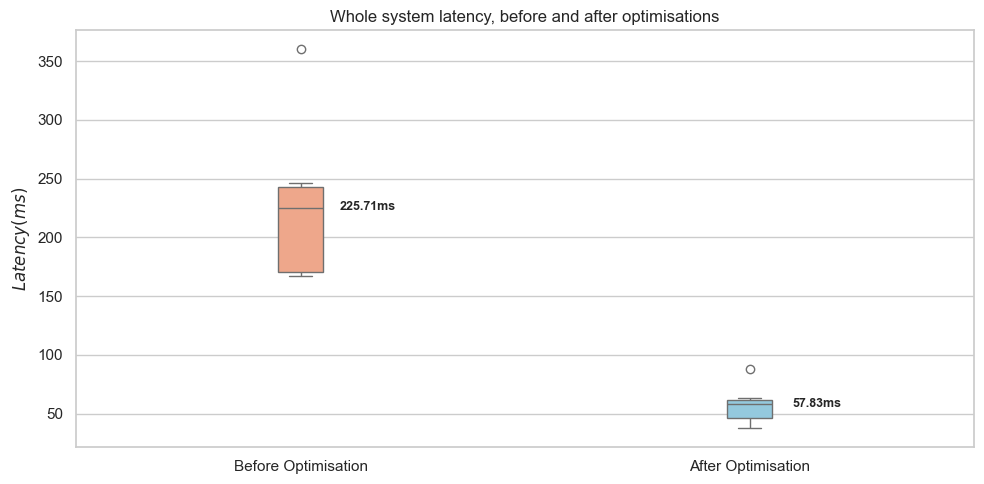

In [63]:

#Box plot for latencies

data = {
    'Test': ['Before Optimisation']*7 + ['After Optimisation']*6,
    'Latency (ms)': [360,240,225,246,167,167,175, 42,58,88,58,38,63]
}

df = pd.DataFrame(data)

# Set style
sns.set_theme(style="whitegrid")

# Create grouped boxplot
plt.figure(figsize=(10, 5))
ax = sns.boxplot(x="Test", y="Latency (ms)", hue="Test", data=df, palette={"Before Optimisation": "lightsalmon", "After Optimisation": "skyblue"}, width=0.1)

latency_1 = df[df['Test']=='Before Optimisation']
avg_1 = latency_1['Latency (ms)'].mean()

latency_2 = df[df['Test']=='After Optimisation']
avg_2 = latency_2['Latency (ms)'].mean()

plt.text(0.15,avg_1-5,f'{avg_1:.2f}ms',ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.text(1.15,avg_2-5,f'{avg_2:.2f}ms',ha='center', va='bottom', fontsize=9, fontweight='bold')

# Axis labels
ax.set_ylabel(r'$Latency (ms)$')
ax.set_xlabel('')

# Legend


plt.title('Whole system latency, before and after optimisations')

# Display plot
plt.tight_layout()
plt.show()

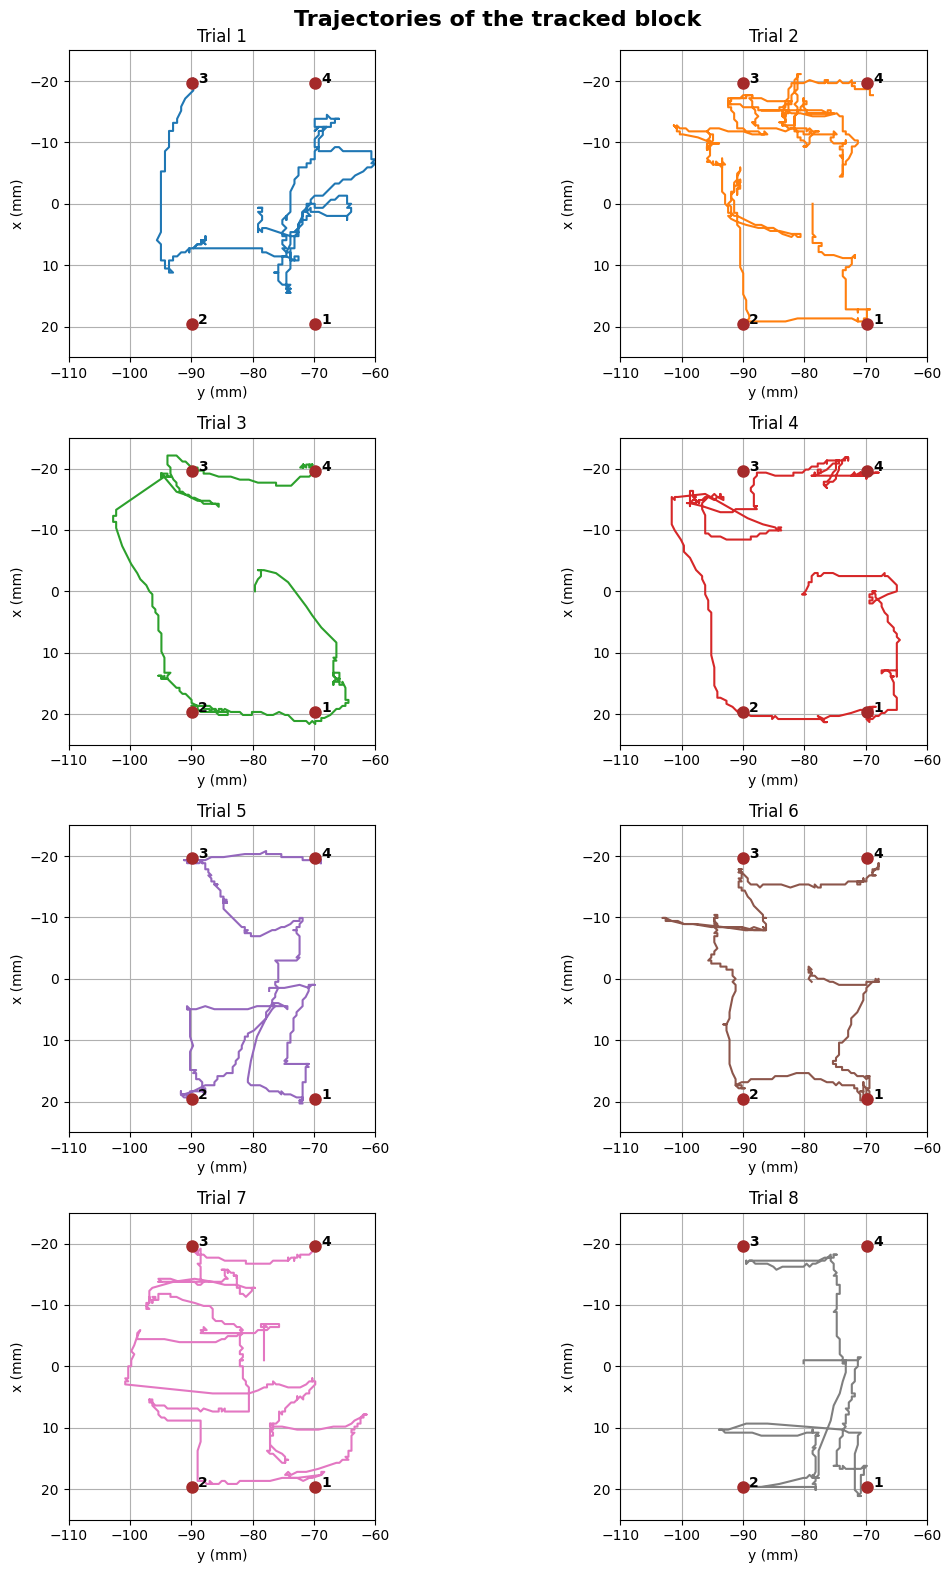

In [4]:
#Trajectory plot for rectangle
from matplotlib.lines import Line2D
import numpy as np
import glob
import os
THRESHOLD= 4.0
data_paths = glob.glob(f".//output//rectangle//*.csv")
# Dummy example data: 8 trials of a rectangular path
trials = []
for path in data_paths[:-1]:
    df = pd.read_csv(path)
    targets = df[['Target_x','Target_y']].drop_duplicates().to_numpy()
    start_index = len(df[(df['Target_x'] == targets[0][0]) & (df['Target_y'] == targets[0][1])])
    block = df[['Block_x','Block_y']]
    block = block[start_index:].to_numpy().swapaxes(0,1)
    trials.append(block)

ploted_targets = targets[1:].swapaxes(0,1)



fig, axs = plt.subplots(4, 2, figsize=(12, 16))
fig.suptitle("Trajectories of the tracked block", fontsize=16, fontweight='bold')
axs = axs.flatten()
colors = plt.cm.tab10.colors  # distinct colors

# Plot all trials
for i, (y, x) in enumerate(trials):
    ax = axs[i]
    ax.set_aspect('equal')
    ax.plot(y, x, label=f'Trial {i+1}', color=colors[i % 10])
    

    # Plot key corner points and labels
    corner_y = ploted_targets[0]
    corner_x = ploted_targets[1]
    for j, (cy, cx) in enumerate(zip(corner_y, corner_x), 1):
        ax.plot(cy, cx, 'o', color='brown', markersize=8)
        ax.text(cy + 1, cx, str(j), fontsize=10, fontweight='bold')

    # Flip axes
    
    ax.invert_xaxis()
    ax.invert_yaxis()

    # Labels and legend
    ax.set_title(f'Trial {i+1}')
    ax.set_xlabel('y (mm)')
    ax.set_ylabel('x (mm)')
    ax.set_xlim(-110,-60)
    ax.set_ylim(25,-25)
    ax.grid(True)

# Hide unused axes if any
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])
plt.tight_layout()
plt.show()

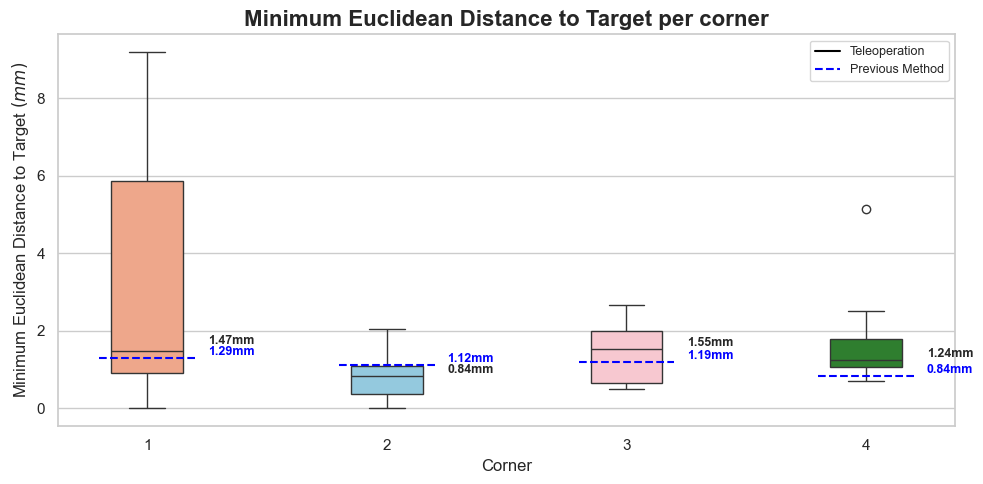

In [143]:
distance_from_target = []
for path in data_paths[:-1]:
    df = pd.read_csv(path)
    targets = df[['Target_x','Target_y']].drop_duplicates().to_numpy()
    start_index = len(df[(df['Target_x'] == targets[0][0]) & (df['Target_y'] == targets[0][1])])
    block = df[['Block_x','Block_y']]
    block = block[start_index:].to_numpy().swapaxes(0,1)
    target_data = []
    targets = targets[1:5]
    for target in targets:
        target_data.append(df[(df['Target_x'] == target[0]) & (df['Target_y'] == target[1])])

    for i,target in enumerate(target_data):
        start_time = target.iloc[0]['Timestamp']
        distance = np.linalg.norm(target[['Block_x','Block_y']].to_numpy()-target[['Target_x','Target_y']].to_numpy(),axis=1)
        completed_index = np.argmax(distance<THRESHOLD)
        distance_from_target.append(np.min(distance))


#Box plot for latencies

data = {
    'Corner': ['1']*8 + ['2']*8 + ['3']*8 + ['4']*8,
    'Euclidean Distance to Target (mm)': distance_from_target
}

benchmark_values = {'1': 1.29, '2': 1.12, '3': 1.19, '4': 0.841}

positions = {'1': 0, '2': 1, '3': 2, '4': 3}
box_width = 0.2  # match your boxplot width

df = pd.DataFrame(data)

# Set style
sns.set_theme(style="whitegrid")

# Create grouped boxplot
plt.figure(figsize=(10, 5))
ax = sns.boxplot(x="Corner", y="Euclidean Distance to Target (mm)", hue="Corner", data=df, palette={"1": "lightsalmon", "2": "skyblue", "3": "pink", "4":"forestgreen"}, width=0.3)

from matplotlib.lines import Line2D

# Custom legend elements
box_handle = Line2D([0], [0], color='black', linestyle='-', linewidth=1.5, label='Teleoperation')
benchmark_handle = Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5, label='Previous Method')

# Manually set legend with only these two
ax.legend(handles=[box_handle, benchmark_handle], loc='upper right', fontsize=9)

for corner, y in benchmark_values.items():
    x_center = positions[corner]
    ax.hlines(y=y, xmin=x_center - box_width, xmax=x_center + box_width,
              colors='blue', linestyles='--', linewidth=1.5, label=f'Benchmark {corner}' if x_center == 0 else None)

plt.text(0.35,benchmark_values['1'],f'{benchmark_values['1']:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold',color='blue')
plt.text(1.35,benchmark_values['2'],f'{benchmark_values['2']:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold',color='blue')
plt.text(2.35,benchmark_values['3'],f'{benchmark_values['3']:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold',color='blue')
plt.text(3.35,benchmark_values['4'],f'{benchmark_values['4']:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold',color='blue')

corner_1 = df[df['Corner']=='1']
avg_1 = corner_1['Euclidean Distance to Target (mm)'].median()

corner_2 = df[df['Corner']=='2']
avg_2 = corner_2['Euclidean Distance to Target (mm)'].median()

corner_3 = df[df['Corner']=='3']
avg_3 = corner_3['Euclidean Distance to Target (mm)'].median()

corner_4 = df[df['Corner']=='4']
avg_4 = corner_4['Euclidean Distance to Target (mm)'].median()

plt.text(0.35,avg_1+0.1,f'{avg_1:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.text(1.35,avg_2,f'{avg_2:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.text(2.35,avg_3,f'{avg_3:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.text(3.35,avg_4,f'{avg_4:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold')

# Axis labels
ax.set_ylabel(r'Minimum Euclidean Distance to Target $(mm)$')
ax.set_xlabel('Corner')



plt.title('Minimum Euclidean Distance to Target per corner',fontsize=16, fontweight='bold')

# Display plot
plt.tight_layout()
plt.show()

30


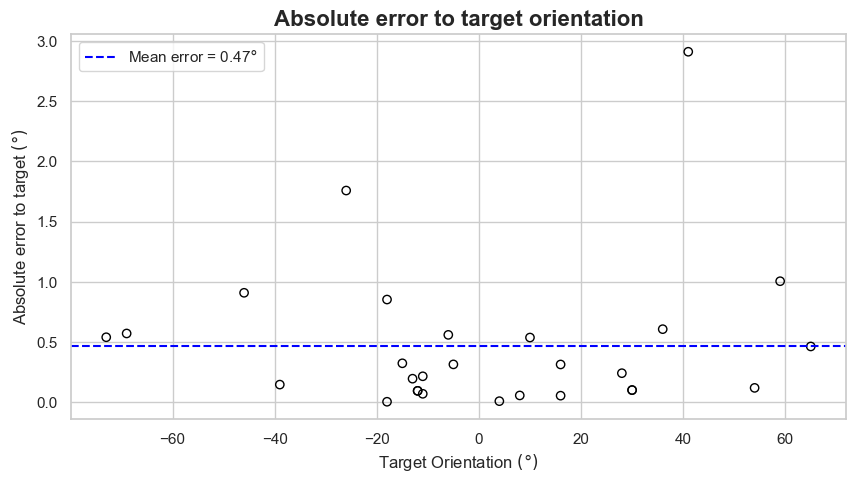

In [114]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import glob



THRESHOLD= 4.0
data_paths = glob.glob(f".//output//orientation_david//*.csv") + glob.glob(f".//output//orientation_david_large//*.csv")
print(len(data_paths))
orientation_data = []

def get_accuracy_data(path):
    df = pd.read_csv(path)
    targets = df[['Target_orientation']].drop_duplicates().to_numpy()
    start_index = len(df[ (df['Target_orientation'] == targets[0][0]) ])
    block = df[['Block_orientation']]
    block = block[start_index:].to_numpy()
    target_data = []
    for target in targets:
        target_data.append(df[(df['Target_orientation'] == target[0])])

    target = target_data[-1]
    target_orientation = targets[-1]
    distance = np.linalg.norm(target[['Block_orientation']].to_numpy()-target[['Target_orientation']].to_numpy(),axis=1)
    return(target_orientation[0],np.min(distance))



for path in data_paths:
    data = get_accuracy_data(path)
    orientation_data.append((data[0],data[1]))



orientation_data = np.array(orientation_data)
orientation_data = orientation_data.swapaxes(0,1)

sd = np.sqrt(orientation_data[1].var())
outliers = np.where(orientation_data[1]>3*sd)
clean_orientation_data = [[],[]]
clean_orientation_data[0] = np.delete(orientation_data[0],outliers)
clean_orientation_data[1]= np.delete(orientation_data[1],outliers)

median = np.mean(clean_orientation_data[1])

plt.figure(figsize=(10, 5))
plt.xlabel(r"Target Orientation $(\degree)$")
plt.ylabel(r"Absolute error to target $(\degree)$")
plt.grid(visible=True)
plt.title('Absolute error to target orientation',fontsize=16, fontweight='bold')
plt.axhline(median, color='blue', linestyle='--', linewidth=1.5, label=rf'Mean error = {median:.2f}$\degree$')
plt.scatter(clean_orientation_data[0],clean_orientation_data[1], marker='o' ,facecolors='none', edgecolors='black')
plt.legend()
plt.show()

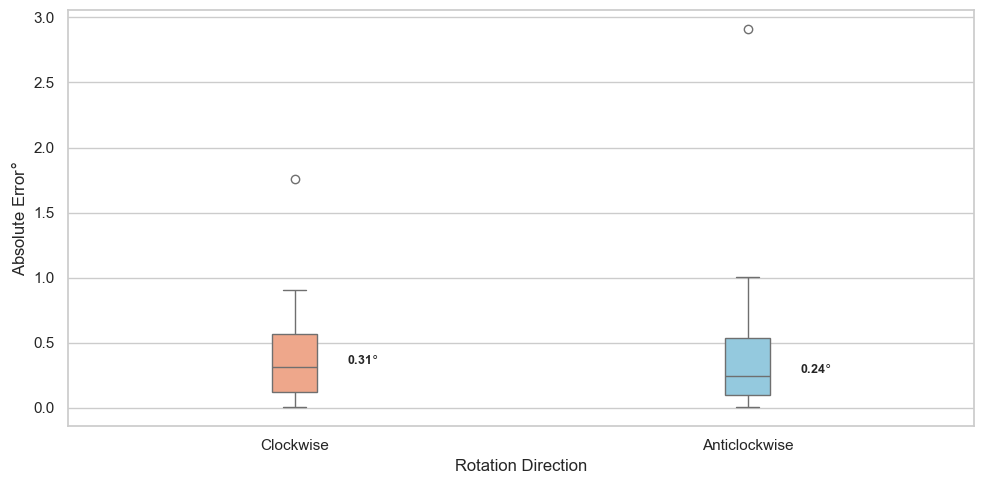

In [115]:
orientation_bins = []
orientation_bins.append([clean_orientation_data[1][i] 
                    for i in range(len(clean_orientation_data[0])) 
                    if clean_orientation_data[0][i] < 0])
orientation_bins.append([clean_orientation_data[1][i] 
                    for i in range(len(clean_orientation_data[0])) 
                    if clean_orientation_data[0][i] > 0])
clockwise_len = len(orientation_bins[0])
anticlockwise_len = len(orientation_bins[1])
data = {
    'Rotation': ['Clockwise']*clockwise_len + ['Anticlockwise']*anticlockwise_len,
    'Absolute Error': orientation_bins[0] + orientation_bins[1]
}

df = pd.DataFrame(data)

# Set style
sns.set_theme(style="whitegrid")

# Create grouped boxplot
plt.figure(figsize=(10, 5))
ax = sns.boxplot(x="Rotation", y="Absolute Error", hue="Rotation", data=df, palette={"Clockwise": "lightsalmon", "Anticlockwise": "skyblue"}, width=0.1)

avg_1 = np.median(orientation_bins[0])

avg_2 = np.median(orientation_bins[1])

plt.text(0.15,avg_1,rf'{avg_1:.2f}$\degree$',ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.text(1.15,avg_2,rf'{avg_2:.2f}$\degree$',ha='center', va='bottom', fontsize=9, fontweight='bold')

# Axis labels
ax.set_ylabel(r'Absolute Error$ \degree$')
ax.set_xlabel('Rotation Direction')

# Legend


plt.title('')

# Display plot
plt.tight_layout()
plt.show()

In [116]:
# Pick and place
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import glob
import seaborn as sns



THRESHOLD= 5.0
data_paths = glob.glob(f".//output//peg_in_hole//*.csv")
timing_data = []

def get_timing_data(path):
    df = pd.read_csv(path)
    targets = df[['Target_x','Target_y']].drop_duplicates().to_numpy()
    start_index = len(df[(df['Target_x'] == targets[0][0]) & (df['Target_y'] == targets[0][1])])
    block = df[['Block_x','Block_y']]
    block = block[start_index:].to_numpy()
    target_data = []
    output = []
    for target in targets:
        target_data.append(df[(df['Target_x'] == target[0]) & (df['Target_y'] == target[1])])

    for target in target_data:
        start_time = target.iloc[0]['Timestamp']
        distance = np.linalg.norm(target[['Block_x','Block_y']].to_numpy()-target[['Target_x','Target_y']].to_numpy(),axis=1)
        completed_index = np.argmax(distance<THRESHOLD)
        end_time = target.iloc[completed_index]['Timestamp']
        output.append(((end_time-start_time),np.min(distance)))

    return output


for path in data_paths:
    data = get_timing_data(path)
    timing_data.append((data[-1][0],get_timing_data(path)[-1][1]))

format_data = np.array(timing_data).swapaxes(0,1)
david_time_data = format_data[0]
david_error_data = format_data[1]

data_paths = glob.glob(f".//output//peg_in_hole_raph//*.csv")
timing_data = []


for path in data_paths:
    data = get_timing_data(path)
    timing_data.append((data[-1][0],get_timing_data(path)[-1][1]))

format_data = np.array(timing_data).swapaxes(0,1)
raph_time_data = format_data[0]
raph_error_data = format_data[1]



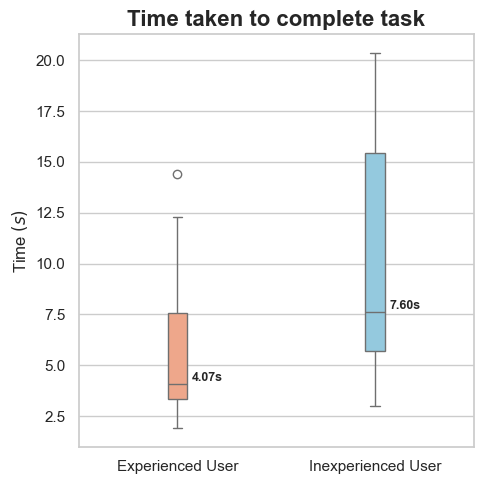

In [120]:
data = {
    'User': ['Experienced User']*len(david_time_data) + ['Inexperienced User']*len(raph_time_data),
    'Time to complete': david_time_data.tolist() + raph_time_data.tolist()
}

df = pd.DataFrame(data)

# Set style
sns.set_theme(style="whitegrid")

# Create grouped boxplot
plt.figure(figsize=(5, 5))
ax = sns.boxplot(x="User", y="Time to complete", hue="User", data=df, palette={"Experienced User": "lightsalmon", "Inexperienced User": "skyblue"}, width=0.1)

avg_1 = np.median(david_time_data)

avg_2 = np.median(raph_time_data)

plt.text(0.15,avg_1,f'{avg_1:.2f}s',ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.text(1.15,avg_2,f'{avg_2:.2f}s',ha='center', va='bottom', fontsize=9, fontweight='bold')

# Axis labels
ax.set_ylabel(r'Time $(s)$')
ax.set_xlabel('')

# Legend


plt.title('Time taken to complete task',fontsize=16, fontweight='bold')

# Display plot
plt.tight_layout()
plt.show()

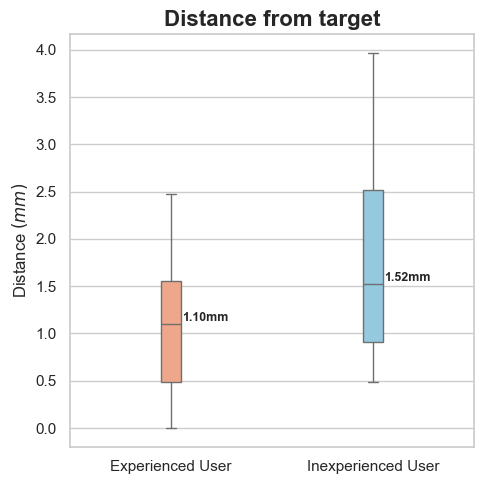

In [119]:
data = {
    'User': ['Experienced User']*len(david_error_data) + ['Inexperienced User']*len(raph_error_data),
    'Distance from target': david_error_data.tolist() + raph_error_data.tolist()
}

df = pd.DataFrame(data)

# Set style
sns.set_theme(style="whitegrid")

# Create grouped boxplot
plt.figure(figsize=(5, 5))
ax = sns.boxplot(x="User", y="Distance from target", hue="User", data=df, palette={"Experienced User": "lightsalmon", "Inexperienced User": "skyblue"}, width=0.1)

avg_1 = np.median(david_error_data)

avg_2 = np.median(raph_error_data)

plt.text(0.17,avg_1,f'{avg_1:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.text(1.17,avg_2,f'{avg_2:.2f}mm',ha='center', va='bottom', fontsize=9, fontweight='bold')

# Axis labels
ax.set_ylabel(r'Distance $(mm)$')
ax.set_xlabel('')

# Legend


plt.title('Distance from target',fontsize=16, fontweight='bold')

# Display plot
plt.tight_layout()
plt.show()

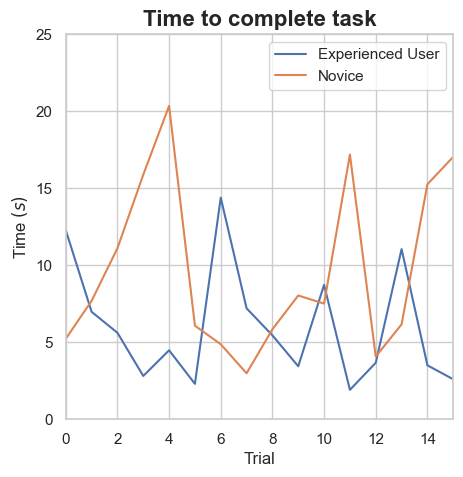

In [136]:
plt.figure(figsize=(5, 5))
plt.title('Time to complete task', fontsize=16, fontweight='bold')
plt.plot(david_time_data,label='Experienced User')
plt.plot(raph_time_data,label='Novice')
plt.ylim(0,25)
plt.xlim(0,15)
plt.xlabel('Trial')
plt.ylabel(r'Time $(s)$')
plt.legend()

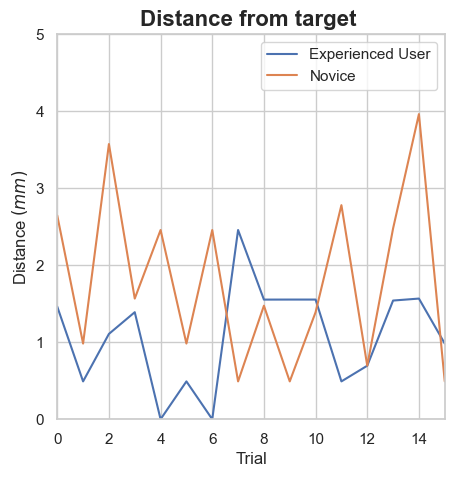

In [137]:
plt.figure(figsize=(5, 5))
plt.title('Distance from target ', fontsize=16, fontweight='bold')
plt.plot(david_error_data,label='Experienced User')
plt.plot(raph_error_data,label='Novice')
plt.ylim(0,5)
plt.xlim(0,15)
plt.xlabel('Trial')
plt.ylabel(r'Distance $(mm)$')
plt.legend()

In [ ]:
#
data = [(2.0,2.032),(2.5,2.32),(4.5,4.0),(2.3,1.84)]
data = np.array(data)
error = [abs(i[1]-i[0]) for i in data]
targets = [i[0] for i in data]
plt.scatter(targets,error)

In [44]:
data_1 = np.array([(-82.6,-76.7),(-93.8,-78.7),(-103.2,-74.9),(-105.8,-72.5)])
distances_1 = [np.linalg.norm(data_1[i]-data_1[i+1]) for i in range(len(data_1)-1)]
data_2 = np.array([(-81.1,-85.6),(-88.0,-85.4),(-97.2,-80.7),(-105.8,-73.3)])
distances_2 = [np.linalg.norm(data_2[i]-data_2[i+1]) for i in range(len(data_2)-1)]
distances = distances_1+distances_2
10.0 - np.mean(distances)

np.float64(1.0610053864018507)